In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("insurance.csv")
df.head()
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


<!-- Data Cleaning. -->

In [3]:
df.isnull().sum()
df.duplicated().sum()
df[df.duplicated()]
df = df.drop_duplicates()
df.dtypes
print(df["sex"].unique())
print(df["smoker"].unique())
print(df["region"].unique())
df.nunique()
df[["age", "bmi", "children", "charges"]].describe()
df[["sex", "smoker", "region"]].describe()
print("Minimum age:", df["age"].min())
print("Minimum BMI:", df["bmi"].min())
print("Minimum children:", df["children"].min())
print("Minimum charges:", df["charges"].min())
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())

['female' 'male']
['yes' 'no']
['southwest' 'southeast' 'northwest' 'northeast']
Minimum age: 18
Minimum BMI: 15.96
Minimum children: 0
Minimum charges: 1121.8739
Rows: 1337
Columns: 7
Missing values: 0
Duplicate rows: 0


In [4]:
# Outlier Analysis

In [5]:
df[["age", "bmi", "children", "charges"]].describe()

,age,bmi,children,charges
count,1337.000000,1337.000000,1337.000000,1337.000000
mean,39.222139,30.663452,1.095737,13279.121487
std,14.044333,6.100468,1.205571,12110.359656
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.290000,0.000000,4746.344000
50%,39.000000,30.400000,1.000000,9386.161300
75%,51.000000,34.700000,2.000000,16657.717450
max,64.000000,53.130000,5.000000,63770.428010


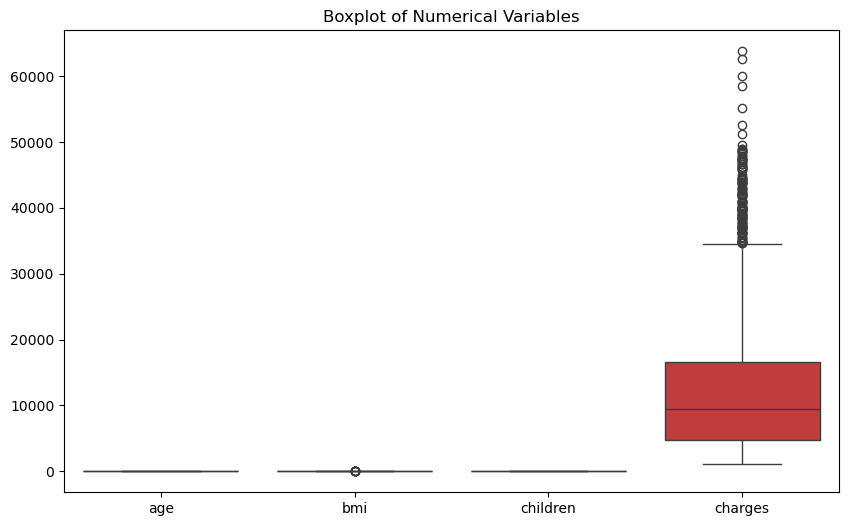

In [6]:

plt.figure(figsize=(10, 6))

sns.boxplot(data=df[["age", "bmi", "children", "charges"]])

plt.title("Boxplot of Numerical Variables")
plt.show()

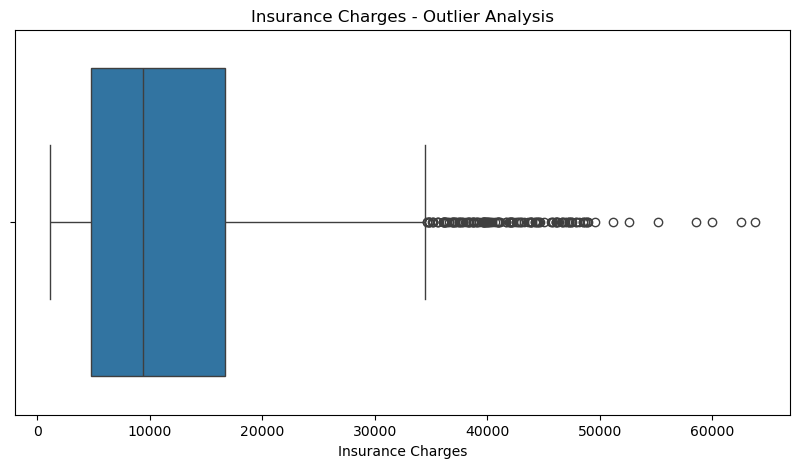

In [7]:
# Check outliers specifically in charges
plt.figure(figsize=(10, 5))

sns.boxplot(x=df["charges"])

plt.title("Insurance Charges - Outlier Analysis")
plt.xlabel("Insurance Charges")

plt.show()

In [8]:
# Exploratory Data Analysis (EDA)

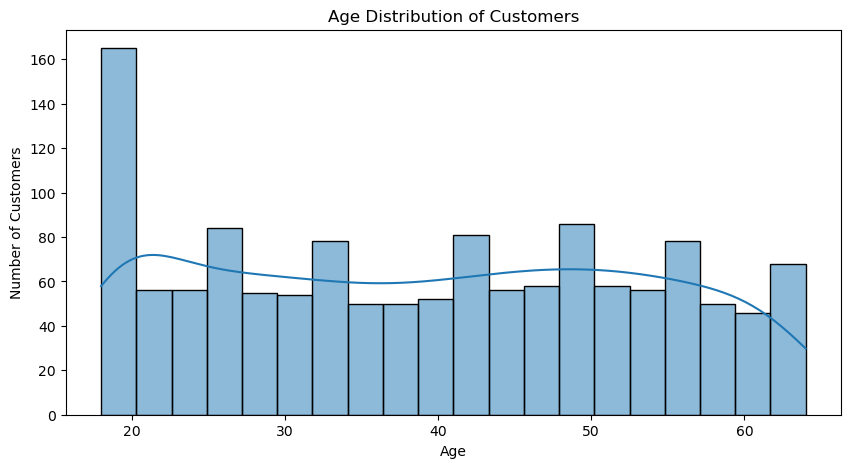

In [9]:
# Age Distribution

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="age", bins=20, kde=True)

plt.title("Age Distribution of Customers")
plt.xlabel("Age")
plt.ylabel("Number of Customers")

plt.show()

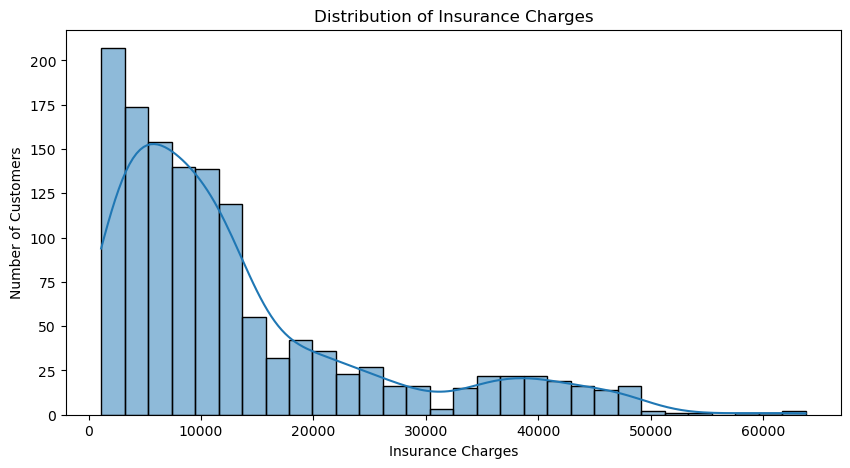

In [10]:
# Insurance Charges Distribution

plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="charges", bins=30, kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Insurance Charges")
plt.ylabel("Number of Customers")

plt.show()

In [11]:
# Smoker vs Insurance Charges

df.groupby("smoker")["charges"].mean()

smoker
no      8440.660307
yes    32050.231832
Name: charges, dtype: float64

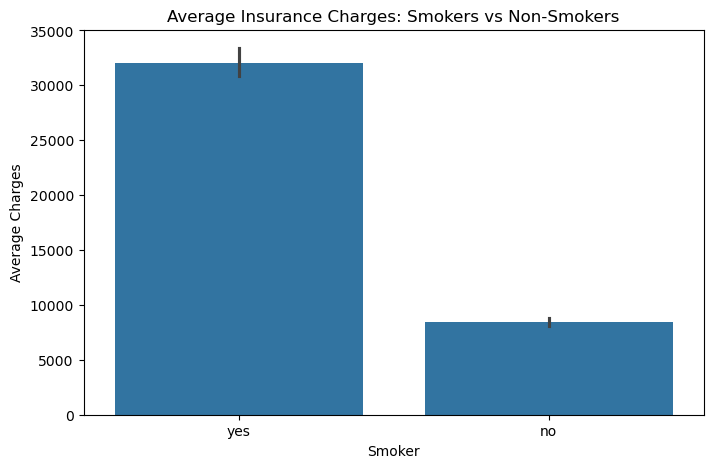

In [12]:
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="smoker", y="charges")

plt.title("Average Insurance Charges: Smokers vs Non-Smokers")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")

plt.show()

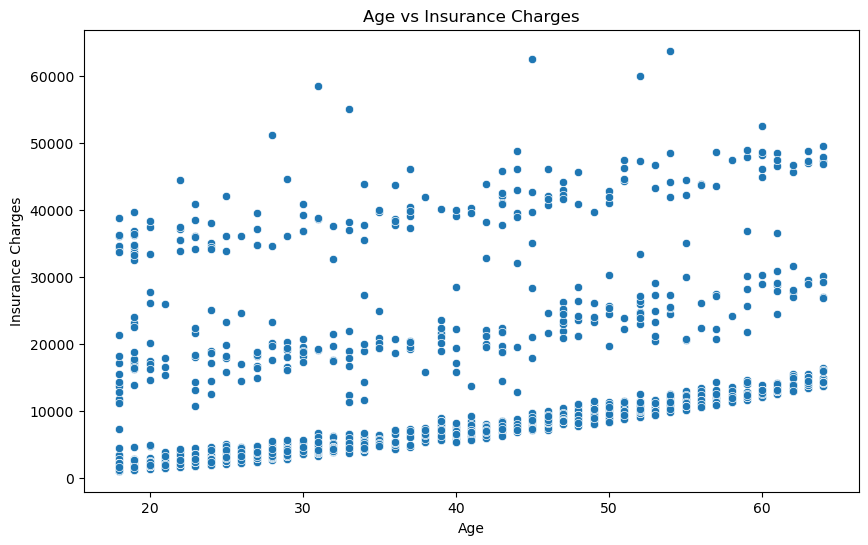

In [13]:
# Age vs Insurance Charges

plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="age", y="charges")

plt.title("Age vs Insurance Charges")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

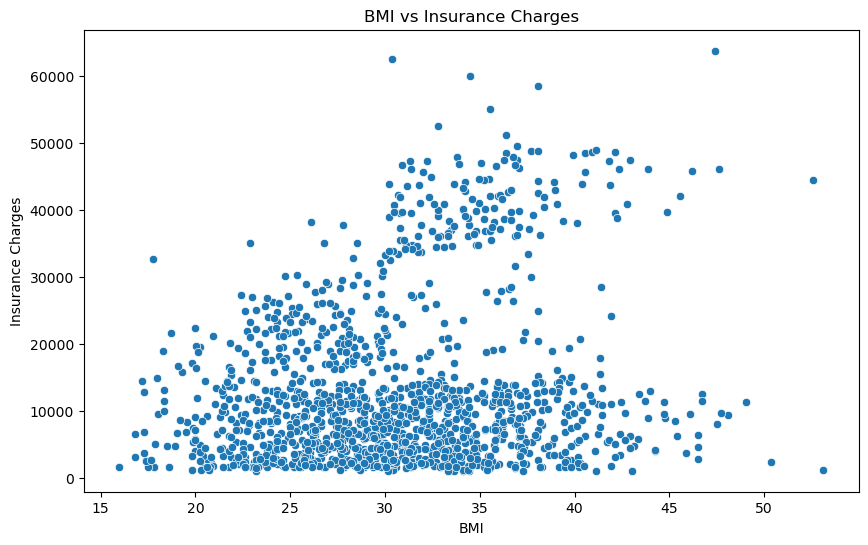

In [14]:
# BMI vs Insurance Charges
plt.figure(figsize=(10, 6))

sns.scatterplot(data=df, x="bmi", y="charges")

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

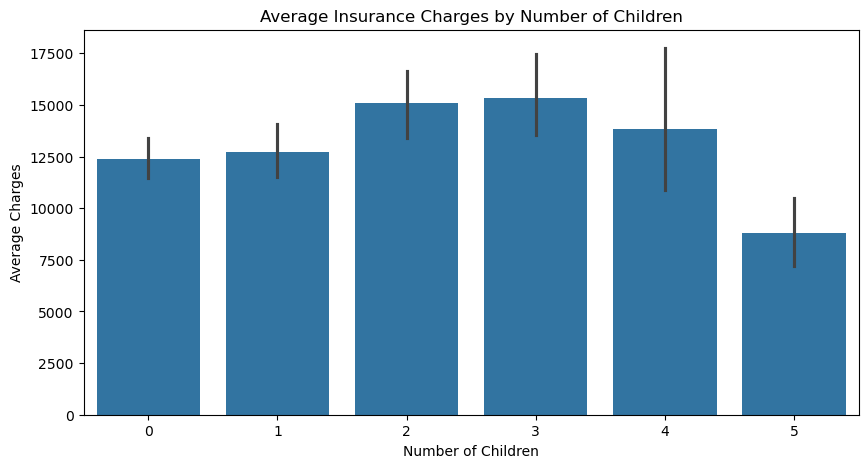

In [15]:
# Number of Children vs Charges
df.groupby("children")["charges"].mean()
plt.figure(figsize=(10, 5))

sns.barplot(data=df, x="children", y="charges")

plt.title("Average Insurance Charges by Number of Children")
plt.xlabel("Number of Children")
plt.ylabel("Average Charges")

plt.show()

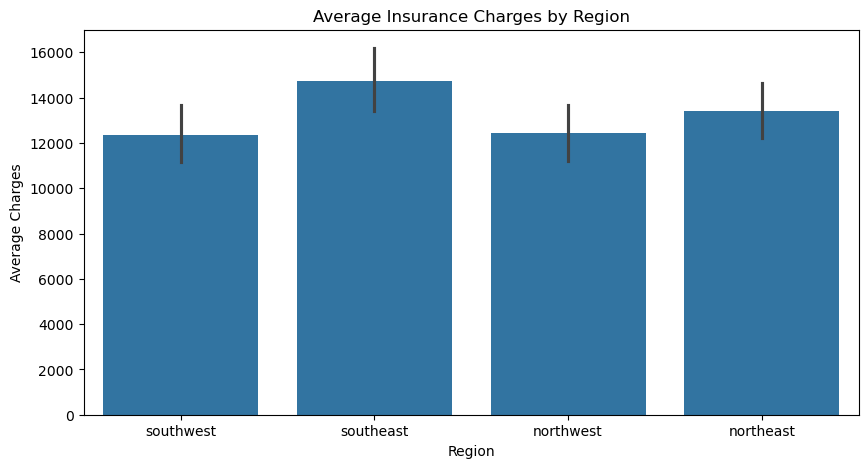

In [16]:
# Region vs Charges
plt.figure(figsize=(10, 5))

sns.barplot(data=df, x="region", y="charges")

plt.title("Average Insurance Charges by Region")
plt.xlabel("Region")
plt.ylabel("Average Charges")

plt.show()

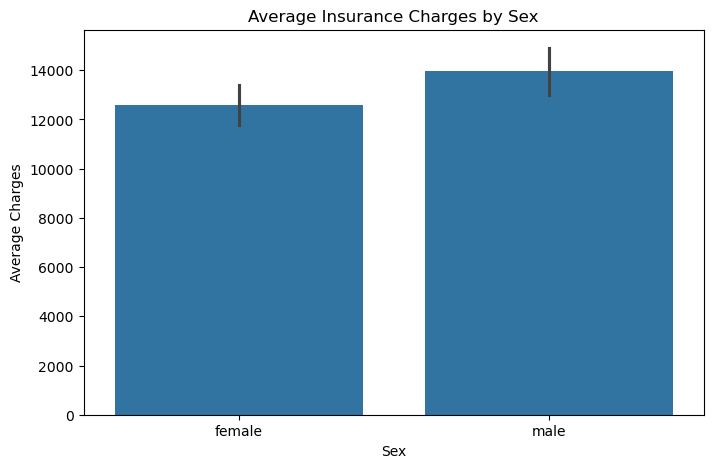

In [17]:
# Sex vs Charges
plt.figure(figsize=(8, 5))

sns.barplot(data=df, x="sex", y="charges")

plt.title("Average Insurance Charges by Sex")
plt.xlabel("Sex")
plt.ylabel("Average Charges")

plt.show()

In [18]:
# Correlation Analysis
df[["age", "bmi", "children", "charges"]].corr()

,age,bmi,children,charges
age,1.000000,0.109344,0.041536,0.298308
bmi,0.109344,1.000000,0.012755,0.198401
children,0.041536,0.012755,1.000000,0.067389
charges,0.298308,0.198401,0.067389,1.000000


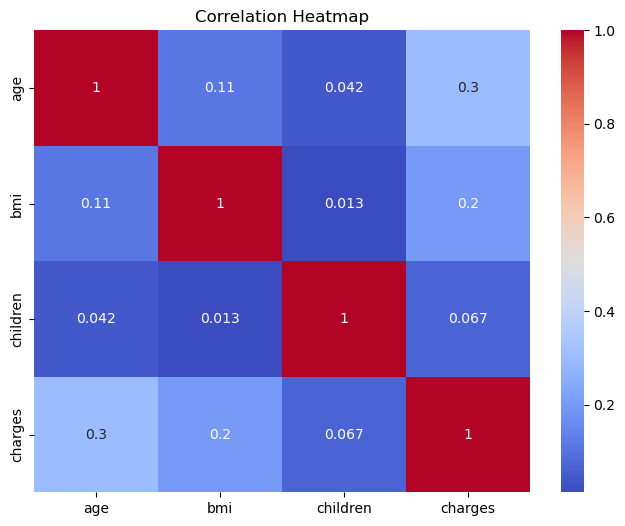

In [19]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    df[["age", "bmi", "children", "charges"]].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.show()

In [20]:
# Advanced EDA & Business Insights

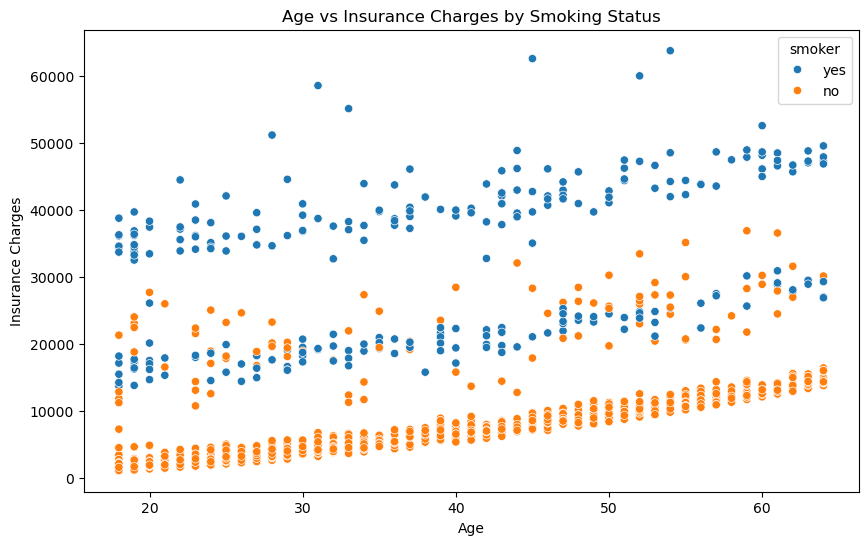

In [21]:
# Smoker + Age vs Charges

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="age",
    y="charges",
    hue="smoker"
)

plt.title("Age vs Insurance Charges by Smoking Status")
plt.xlabel("Age")
plt.ylabel("Insurance Charges")

plt.show()

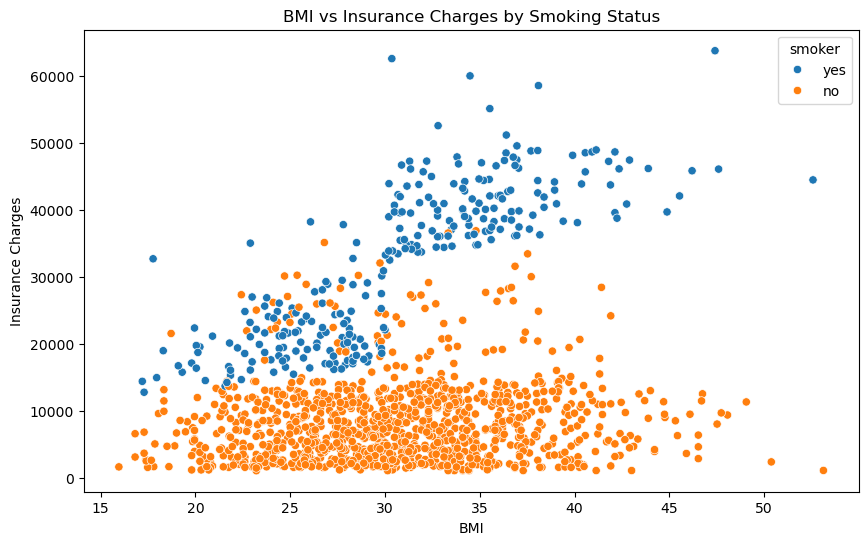

In [22]:
# Smoker + BMI vs Charges

plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges",
    hue="smoker"
)

plt.title("BMI vs Insurance Charges by Smoking Status")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

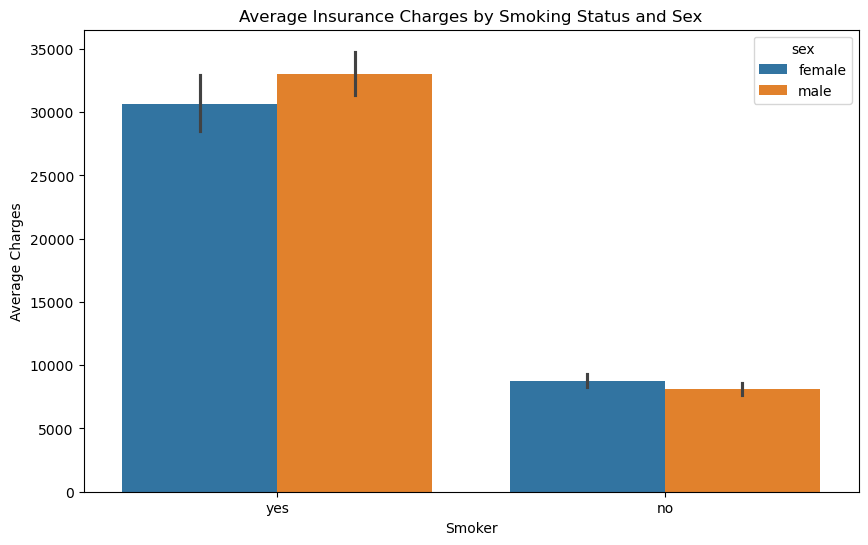

In [23]:
# Smoker + Sex vs Charges

plt.figure(figsize=(10, 6))

sns.barplot(
    data=df,
    x="smoker",
    y="charges",
    hue="sex"
)

plt.title("Average Insurance Charges by Smoking Status and Sex")
plt.xlabel("Smoker")
plt.ylabel("Average Charges")

plt.show()

In [26]:
# making age groups

bins = [17, 25, 35, 50, 65, 100]

labels = [
    "18-25",
    "26-35",
    "36-50",
    "51-65",
    "66+"
]

df["age_group"] = pd.cut(
    df["age"],
    bins=bins,
    labels=labels
)

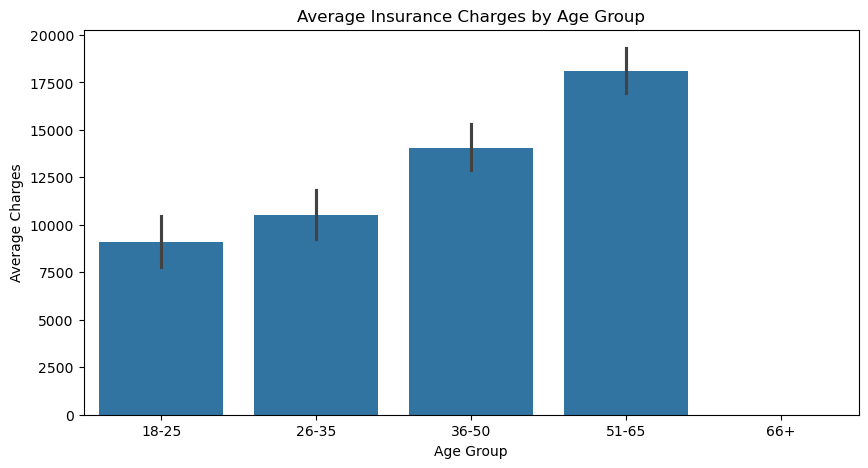

In [27]:
# Age Group vs Charges
df.groupby("age_group", observed=True)["charges"].mean()
plt.figure(figsize=(10, 5))

sns.barplot(
    data=df,
    x="age_group",
    y="charges"
)

plt.title("Average Insurance Charges by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Average Charges")

plt.show()

In [28]:
# High-Cost Customers

high_cost_threshold = df["charges"].quantile(0.75)

high_cost_threshold

np.float64(16657.71745)

In [29]:
high_cost_customers = df[
    df["charges"] > high_cost_threshold
]

In [30]:
high_cost_customers.head()

,age,sex,bmi,children,smoker,region,charges,age_group
0,19,female,27.900,0,yes,southwest,16884.92400,18-25
3,33,male,22.705,0,no,northwest,21984.47061,26-35
9,60,female,25.840,0,no,northwest,28923.13692,51-65
11,62,female,26.290,0,yes,southeast,27808.72510,51-65
14,27,male,42.130,0,yes,southeast,39611.75770,26-35


In [31]:
high_cost_customers["smoker"].value_counts(normalize=True) * 100

smoker
yes    76.047904
no     23.952096
Name: proportion, dtype: float64

In [32]:
df.groupby(["smoker", "sex"])["charges"].mean()

smoker  sex   
no      female     8762.297300
        male       8099.700161
yes     female    30678.996276
        male      33042.005975
Name: charges, dtype: float64

In [33]:
df.groupby("age_group", observed=True)["charges"].mean()

age_group
18-25     9111.433685
26-35    10495.163047
36-50    14029.997563
51-65    18084.987223
Name: charges, dtype: float64

In [34]:
high_cost_threshold = df["charges"].quantile(0.75)
high_cost_threshold

np.float64(16657.71745)

In [35]:
high_cost_customers["smoker"].value_counts(normalize=True) * 100

smoker
yes    76.047904
no     23.952096
Name: proportion, dtype: float64

In [ ]:
#                                                                         BMI Analysis

In [36]:
df["bmi"].describe()

count    1337.000000
mean       30.663452
std         6.100468
min        15.960000
25%        26.290000
50%        30.400000
75%        34.700000
max        53.130000
Name: bmi, dtype: float64

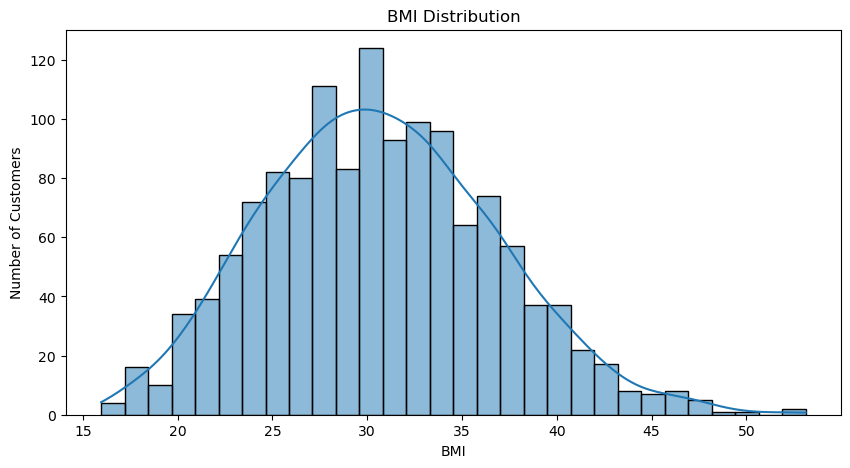

In [37]:
plt.figure(figsize=(10, 5))

sns.histplot(data=df, x="bmi", bins=30, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Number of Customers")

plt.show()

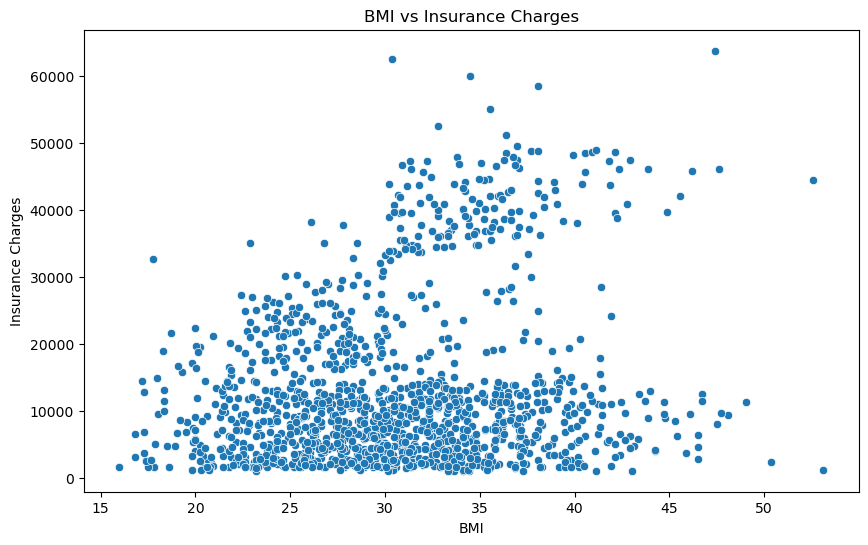

In [38]:
# BMI vs Charges
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="bmi",
    y="charges"
)

plt.title("BMI vs Insurance Charges")
plt.xlabel("BMI")
plt.ylabel("Insurance Charges")

plt.show()

In [40]:
# family_size
df["family_size"] = df["children"] + 1
df[["children", "family_size"]].head(10)

,children,family_size
0,0,1
1,1,2
2,3,4
3,0,1
4,0,1
5,0,1
6,1,2
7,3,4
8,2,3
9,0,1


In [43]:
# smoker_flag

df["smoker_flag"] = df["smoker"].map({
    "yes": 1,
    "no": 0
})
df[["smoker", "smoker_flag"]].head(10)
df["smoker_flag"].value_counts()

smoker_flag
0    1063
1     274
Name: count, dtype: int64

In [46]:
df.to_csv("cleaned_data.csv", index=False)


In [47]:
df

,customer_id,age,sex,bmi,children,smoker,region,charges,age_group,family_size,smoker_flag
0,1,19,female,27.900,0,yes,southwest,16884.92400,18-25,1,1
1,2,18,male,33.770,1,no,southeast,1725.55230,18-25,2,0
2,3,28,male,33.000,3,no,southeast,4449.46200,26-35,4,0
3,4,33,male,22.705,0,no,northwest,21984.47061,26-35,1,0
4,5,32,male,28.880,0,no,northwest,3866.85520,26-35,1,0
...,...,...,...,...,...,...,...,...,...,...,...
1333,1333,50,male,30.970,3,no,northwest,10600.54830,36-50,4,0
1334,1334,18,female,31.920,0,no,northeast,2205.98080,18-25,1,0
1335,1335,18,female,36.850,0,no,southeast,1629.83350,18-25,1,0
1336,1336,21,female,25.800,0,no,southwest,2007.94500,18-25,1,0
